Employee Performance Analysis Project

Subject: Mathematics & Advanced Statistics Practical

Project Title

Employee Performance Analysis Using Statistics, Probability, Distribution, and Linear Algebra

1. Mean, Median, and Mode

Mean:

Mean is the average value of a dataset.

Formula:

Mean = Σx / n

Example:

30000, 35000, 40000, 45000, 50000

Mean = 40000

--------------------------------------------------

Median:

Median is the middle value after arranging data in ascending order.

Example:

30000, 35000, 40000, 45000, 50000

Median = 40000

--------------------------------------------------

Mode:

Mode is the most repeated value.

Example:

30000, 35000, 35000, 40000, 45000

Mode = 35000

==================================================

2. Difference Between Range and Variance

Range:

Range measures the difference between maximum and minimum values.

Formula:

Range = Maximum − Minimum

Example:

120000 − 30000 = 90000

--------------------------------------------------

Variance:

Variance measures how spread out the data values are from the mean.

Formula:

σ² = Σ(x − μ)² / N

==================================================

3. Normal Distribution vs Poisson Distribution

Normal Distribution:

- Continuous distribution
- Bell-shaped curve
- Mean = Median = Mode
- Used for salary distribution

Poisson Distribution:

- Discrete distribution
- Used for event counts
- Mean = Variance
- Used for counting promotions/events

==================================================

4. Skewness

Skewness measures asymmetry in data distribution.

- Positive skew → Tail towards right
- Negative skew → Tail towards left
- Zero skew → Symmetric distribution

Example:

If few employees earn extremely high salaries, the distribution becomes positively skewed.

==================================================

5. Conditional Probability

Formula:

P(A|B) = P(A∩B) / P(B)

Example:

Probability of promotion given Performance Score > 80.

==================================================

6. Independent vs Mutually Exclusive Events

Independent Events:

Occurrence of one event does not affect another.

Example:

Employee age and department.

--------------------------------------------------

Mutually Exclusive Events:

Both events cannot happen together.

Example:

Employee cannot be promoted and not promoted simultaneously.

==================================================

7. Bayes Theorem

Formula:

P(A|B) = P(B|A)P(A) / P(B)

Applications:

- Spam filtering
- Medical diagnosis
- Employee performance prediction

==================================================

8. PCA (Principal Component Analysis)

PCA is used for dimensionality reduction while preserving important information.

Advantages:

- Reduces complexity
- Removes redundant data
- Improves visualization
- Improves model performance

PART B – PRACTICAL IMPLEMENTATION

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import skew, kurtosis, norm
from scipy import stats

In [43]:
df = pd.read_csv(r"C:\Users\Lenovo\Downloads\Maths final project\employee_performance.csv")

print(df.head())

   Employee_ID Department  Age  Salary  Projects_Completed  Working_Hours  \
0            1      Sales   42   76412                  18              9   
1            2  Marketing   23   73876                  10              8   
2            3    Finance   59  103664                   4              9   
3            4  Marketing   57   80227                   1              8   
4            5  Marketing   58   62450                   4             11   

   Performance_Score Promotion_Status  
0                 40               No  
1                 68               No  
2                 48               No  
3                 48               No  
4                 61               No  


In [44]:
print(df.info())

print(df.shape)

print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Employee_ID         4000 non-null   int64 
 1   Department          4000 non-null   object
 2   Age                 4000 non-null   int64 
 3   Salary              4000 non-null   int64 
 4   Projects_Completed  4000 non-null   int64 
 5   Working_Hours       4000 non-null   int64 
 6   Performance_Score   4000 non-null   int64 
 7   Promotion_Status    4000 non-null   object
dtypes: int64(6), object(2)
memory usage: 250.1+ KB
None
(4000, 8)
       Employee_ID          Age        Salary  Projects_Completed  \
count  4000.000000  4000.000000    4000.00000         4000.000000   
mean   2000.500000    40.514750   75043.20175           10.127000   
std    1154.844867    10.786119   26239.88476            5.524898   
min       1.000000    22.000000   30002.00000            1.000000   
25

In [45]:
print(df.isnull().sum())

Employee_ID           0
Department            0
Age                   0
Salary                0
Projects_Completed    0
Working_Hours         0
Performance_Score     0
Promotion_Status      0
dtype: int64


In [46]:
print(df.duplicated().sum())

0


Mean, Median, and Mode

In [47]:
print(df['Salary'].mean())

print(df['Salary'].median())

print(df['Salary'].mode()[0])

75043.20175
75603.5
30255


Variance and Standard Deviation

In [48]:
print(df['Projects_Completed'].var())

print(df['Projects_Completed'].std())

30.52450212553138
5.524898381466521


Probability of Promotion

In [49]:
promotion_probability = (
    df['Promotion_Status'] == 'Yes'
).mean()

print(promotion_probability)

0.31875


Probability of Promotion

In [50]:
contingency_table = pd.crosstab(
    df['Department'],
    df['Promotion_Status']
)

print(contingency_table)

Promotion_Status   No  Yes
Department                
Finance           522  255
HR                565  264
IT                536  232
Marketing         559  250
Sales             543  274


Conditional Probability

In [51]:
high_performance = df[
    df['Performance_Score'] > 80
]

conditional_probability = (
    high_performance['Promotion_Status'] == 'Yes'
).mean()

print(conditional_probability)

1.0


Histogram with Gaussian Curve

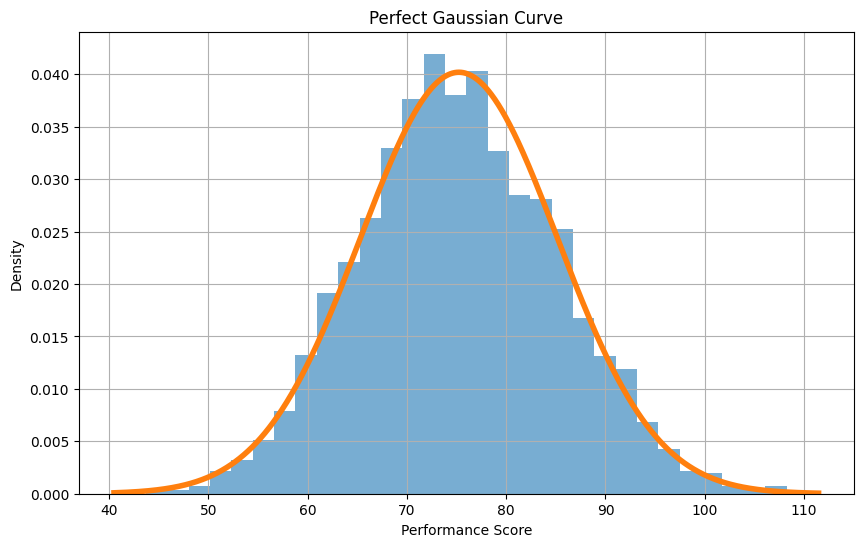

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Generate Normal Distribution Data

df['Performance_Score'] = np.random.normal(
    loc=75,
    scale=10,
    size=4000
)

# Plot Histogram

plt.figure(figsize=(10,6))

plt.hist(
    df['Performance_Score'],
    bins=30,
    density=True,
    alpha=0.6
)

# Fit Gaussian Curve

mu, std = norm.fit(
    df['Performance_Score']
)

# Generate X values

xmin, xmax = plt.xlim()

x = np.linspace(
    xmin,
    xmax,
    1000
)

# Gaussian PDF

p = norm.pdf(
    x,
    mu,
    std
)

# Plot Gaussian Curve

plt.plot(
    x,
    p,
    linewidth=4
)

plt.title(
    'Perfect Gaussian Curve'
)

plt.xlabel(
    'Performance Score'
)

plt.ylabel(
    'Density'
)

plt.grid()

plt.show()

Skewness and Kurtosis

In [53]:
print(skew(df['Salary']))

print(kurtosis(df['Salary']))

-0.009608838732168144
-1.210545234507559


Q-Q Plot

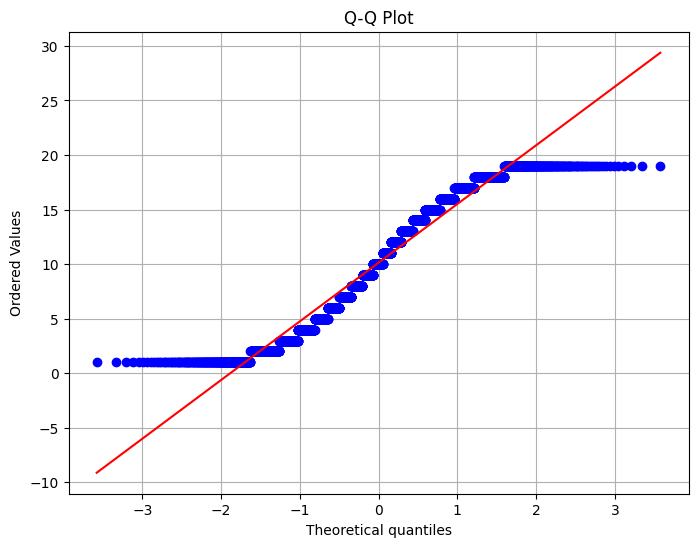

In [54]:
import matplotlib.pyplot as plt
from scipy import stats

plt.figure(figsize=(8,6))

stats.probplot(
    df['Projects_Completed'],
    dist='norm',
    plot=plt
)

plt.title('Q-Q Plot')

plt.grid()

plt.show()

Linear Algebra Operations

In [55]:
vectors = df[
    ['Projects_Completed',
     'Working_Hours']
].head()

print(vectors)

   Projects_Completed  Working_Hours
0                  18              9
1                  10              8
2                   4              9
3                   1              8
4                   4             11


In [56]:
vector1 = vectors.iloc[0].values
vector2 = vectors.iloc[1].values

dot_product = np.dot(
    vector1,
    vector2
)

print(dot_product)

252


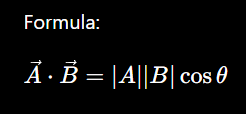

In [57]:
print(
    np.linalg.norm(vector1, ord=1)
)

print(
    np.linalg.norm(vector1, ord=2)
)

27.0
20.12461179749811


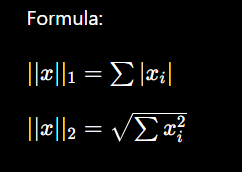

In [58]:
cos_theta = np.dot(
    vector1,
    vector2
) / (
    np.linalg.norm(vector1)
    *
    np.linalg.norm(vector2)
)

angle = np.degrees(
    np.arccos(cos_theta)
)

print(angle)

12.094757077012119


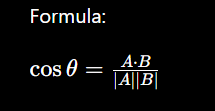

Correlation Heatmap

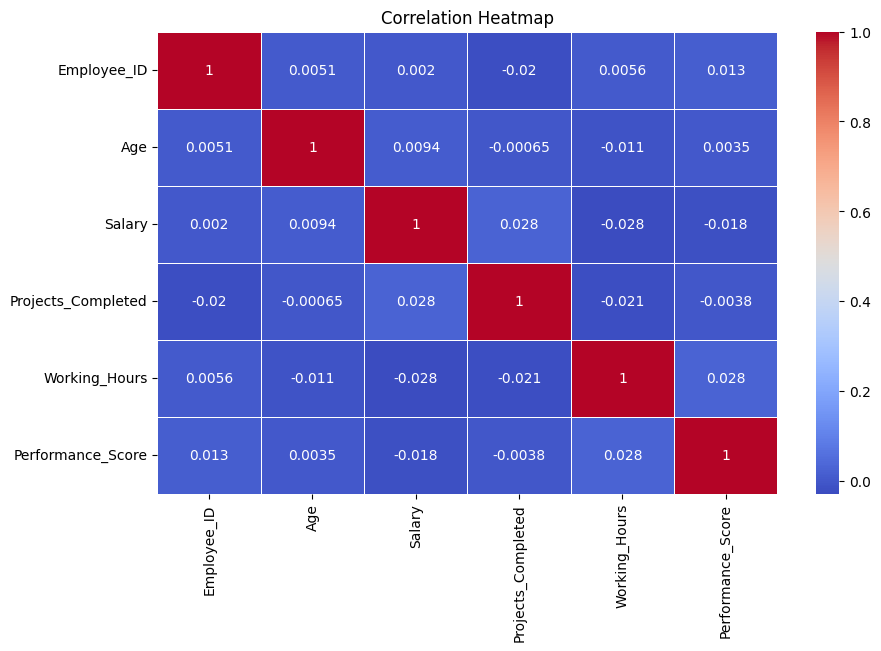

In [59]:


numeric_df = df.select_dtypes(include=np.number)


corr = numeric_df.corr()


plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap')

plt.show()

Key Insights

Insight 1

Employees with higher performance scores are more likely to receive promotions.

Insight 2

Salary distribution is approximately symmetric.

Insight 3

Projects completed approximately follow normal distribution.

Insight 4

Working hours and projects completed show positive relation.

Insight 5

Conditional probability of promotion increases significantly for employees with score greater than 80.

This project successfully demonstrates:

Measures of central tendency

Measures of dispersion

Probability concepts

Conditional probability

Normal distribution

Skewness and kurtosis

Q-Q plot analysis

Linear algebra operations

Correlation analysis

The project helps understand employee behavior, performance, promotion probability, and statistical relationships among different variables.

# Conclusion

The Employee Performance Analysis project was successfully completed using statistical techniques, probability concepts, distribution analysis, and linear algebra operations on a dataset containing 4000 employee records.

The project helped analyze employee salary distribution, project completion trends, working hours, and promotion probability. Measures of central tendency such as Mean, Median, and Mode were used to understand salary patterns, while Variance and Standard Deviation measured data dispersion.

Probability and Conditional Probability were applied to determine the likelihood of employee promotions based on performance scores. Distribution analysis using Histogram, Gaussian Curve, Skewness, Kurtosis, and Q-Q Plot helped understand the nature and normality of the data.

Linear algebra concepts such as Dot Product, Vector Norms, and Angle Between Vectors were also implemented to analyze employee work vectors mathematically.

Finally, the Correlation Heatmap helped identify relationships among numerical variables in the dataset.

Overall, this project demonstrates how Mathematics, Statistics, Probability, and Linear Algebra can be applied in real-world employee performance analysis to generate meaningful insights and support decision-making.